<a href="https://colab.research.google.com/github/fagundespereiraGIT25/MVP_PUCRio_DataScience_Course/blob/main/MVP2_FagundesPereira_PUC_Rio_Classificacao_Sentimento_VersaoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP 2 — Machine Learning & Analytics  
## Classificação de Sentimentos em Avaliações de Filmes do IMDB

**Curso:** Ciência de Dados e Analytics — PUC-Rio  
**Dataset:** IMDB Dataset of 50K Movie Reviews  
**Tipo de problema:** Classificação supervisionada binária  
**Variável de entrada:** `review`  
**Variável-alvo:** `sentiment`  
**Classes:** `positive` e `negative`

Este notebook desenvolve um MVP de Machine Learning & Analytics para classificar automaticamente avaliações de filmes do IMDB como positivas ou negativas.

# 1. Definição do problema

## Contexto

Plataformas digitais recebem diariamente grandes volumes de avaliações textuais. A leitura manual dessas avaliações é inviável em larga escala. Modelos de Machine Learning podem ajudar a classificar automaticamente o sentimento expresso nesses textos, apoiando análises de satisfação, reputação e percepção do público.

## Problema escolhido

Classificar avaliações de filmes do IMDB como **positivas** ou **negativas** a partir do texto escrito pelo usuário.

## Tipo de problema

Este é um problema de **classificação supervisionada binária**, pois há uma variável-alvo conhecida (`sentiment`) com duas classes possíveis: `positive` e `negative`.

## Objetivo do modelo

Construir, comparar e avaliar modelos capazes de identificar automaticamente o sentimento de uma avaliação textual de filme.

## Hipóteses

1. O conteúdo textual das avaliações contém informação suficiente para identificar o sentimento expresso.
2. Modelos de Machine Learning treinados com vetorização textual terão desempenho superior a um baseline ingênuo.
3. Representações baseadas em TF-IDF tendem a superar representações simples baseadas em contagem de palavras.
4. Modelos lineares, como Regressão Logística e Linear SVM, tendem a apresentar bom desempenho em classificação de texto.
5. A otimização de hiperparâmetros pode melhorar o desempenho do modelo escolhido.

# 2. Ambiente e reprodutibilidade

In [ ]:
# Instalações opcionais para o Google Colab.
# Execute apenas se alguma biblioteca não estiver disponível no ambiente.

# !pip install kagglehub wordcloud -q

In [ ]:
import os
import re
import string
import warnings
import time
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

# 3. Carga dos dados

O dataset utilizado é o **IMDB Dataset of 50K Movie Reviews**, disponibilizado no Kaggle.

Para aumentar a reprodutibilidade, a célula abaixo tenta carregar os dados via `kagglehub`. Caso o ambiente não permita o download automático, o notebook também aceita o arquivo `IMDB Dataset.csv` carregado no Colab.

In [38]:
def load_imdb_dataset():

    try:
        import kagglehub
        dataset_dir = kagglehub.dataset_download(
            "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
        )

        csv_candidates = []
        for root, dirs, files in os.walk(dataset_dir):
            for file in files:
                if file.lower().endswith(".csv"):
                    csv_candidates.append(os.path.join(root, file))

        if len(csv_candidates) == 0:
            raise FileNotFoundError("Nenhum arquivo CSV encontrado no diretório baixado.")

        print("Dataset carregado via KaggleHub:")
        print(csv_candidates[0])
        return pd.read_csv(csv_candidates[0])

    except Exception as e:
        print("Não foi possível carregar via KaggleHub.")
        print("Motivo:", e)
        print("Tentando carregar arquivo local...")


    raise FileNotFoundError(
        "Dataset não encontrado. Use KaggleHub ou faça upload do arquivo CSV no Colab."
    )

df = load_imdb_dataset()
print("Dimensão da base:", df.shape)
df.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset carregado via KaggleHub:
/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
Dimensão da base: (50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire p...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue i...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenl...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what mone...",positive


# 4. Apresentação dos dados

O dataset contém avaliações textuais de filmes do IMDB e uma classificação de sentimento associada a cada avaliação.

## Variáveis

- `review`: texto completo da avaliação.
- `sentiment`: sentimento associado à avaliação, podendo ser `positive` ou `negative`.

A variável-alvo é `sentiment`.

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [40]:
df.describe(include="all")

,review,sentiment
count,50000,50000
unique,49582,2
top,"Loved today's show!!! It was a variety and not solely cooking (which would have been great too). Very stimulating and captivating, always keeping the viewer peeking around the corner to see what w...",positive
freq,5,25000


In [41]:
print("Colunas:", df.columns.tolist())
print("Registros duplicados:", df.duplicated().sum())
print("Valores ausentes por coluna:")
display(df.isna().sum())

Colunas: ['review', 'sentiment']
Registros duplicados: 418
Valores ausentes por coluna:


,0
review,0
sentiment,0


# 5. Análise exploratória inicial

Como este é um problema de NLP, serão criados atributos derivados do texto para compreender melhor as avaliações:

- número de caracteres;
- número de palavras;
- tamanho médio das palavras;
- presença de HTML;
- quantidade de pontuação.

In [42]:
df.columns = [col.strip().lower() for col in df.columns]
df = df[["review", "sentiment"]].copy()
df = df.drop_duplicates().reset_index(drop=True)

df["review_length_chars"] = df["review"].astype(str).str.len()
df["review_length_words"] = df["review"].astype(str).str.split().apply(len)
df["avg_word_length"] = df["review_length_chars"] / df["review_length_words"].replace(0, np.nan)
df["html_count"] = df["review"].astype(str).str.count(r"<br\s*/?>|<.*?>", flags=re.IGNORECASE)
df["punctuation_count"] = df["review"].astype(str).apply(lambda x: sum(1 for ch in x if ch in string.punctuation))
df["target"] = df["sentiment"].map({"negative": 0, "positive": 1})

df.head()

,review,sentiment,review_length_chars,review_length_words,avg_word_length,html_count,punctuation_count,target
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me...",positive,1761,307,5.736156,6,78,1
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire p...",positive,998,162,6.160494,6,44,1
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue i...",positive,926,166,5.578313,4,40,1
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenl...,negative,748,138,5.420290,6,42,0
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what mone...",positive,1317,230,5.726087,8,56,1


## 5.1 Distribuição da variável-alvo

,quantidade,percentual
sentiment,,
positive,24884,50.19
negative,24698,49.81


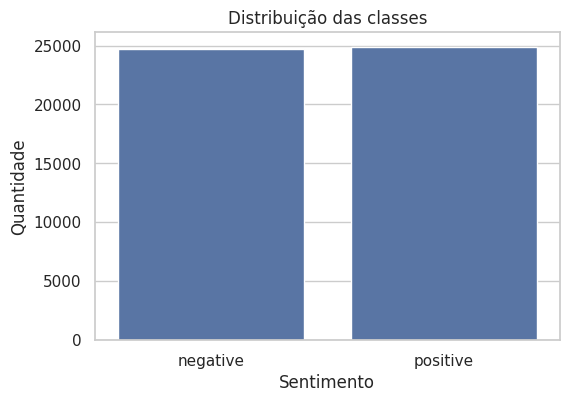

In [43]:
class_counts = df["sentiment"].value_counts()
class_pct = df["sentiment"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "quantidade": class_counts,
    "percentual": class_pct.round(2)
}))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sentiment", order=["negative", "positive"])
plt.title("Distribuição das classes")
plt.xlabel("Sentimento")
plt.ylabel("Quantidade")
plt.show()

### Interpretação

A distribuição das classes permite avaliar se há desbalanceamento. Como as classes positiva e negativa possuem quantidades muito próximas, o problema não apresenta desbalanceamento relevante.

## 5.2 Comprimento das avaliações

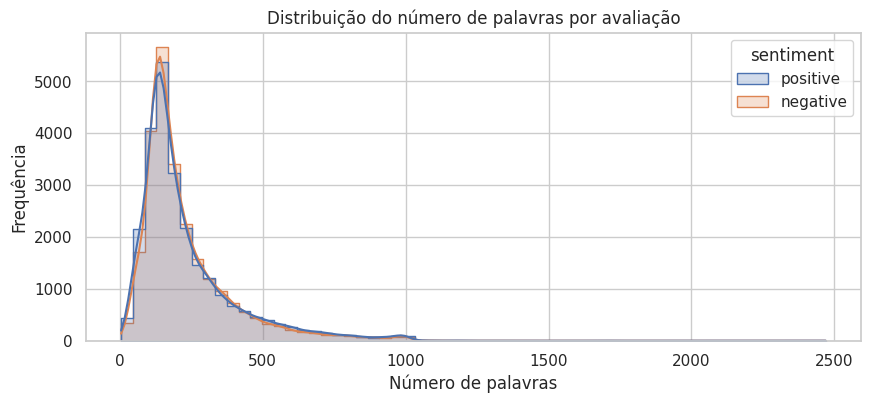

In [44]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="review_length_words", hue="sentiment", bins=60, kde=True, element="step")
plt.title("Distribuição do número de palavras por avaliação")
plt.xlabel("Número de palavras")
plt.ylabel("Frequência")
plt.show()

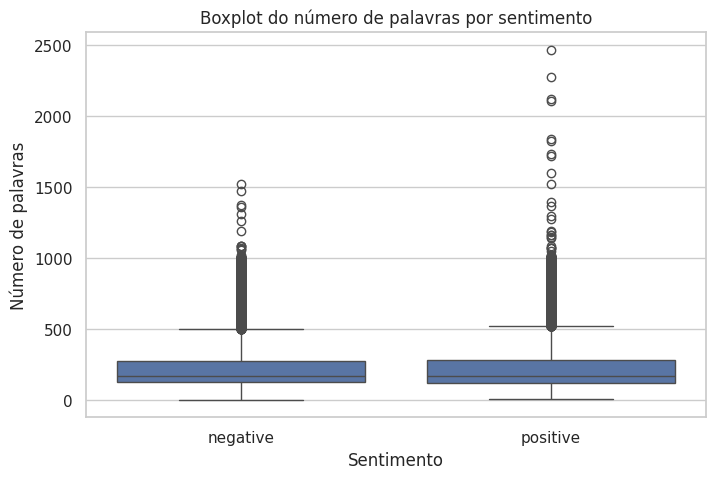

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="sentiment", y="review_length_words", order=["negative", "positive"])
plt.title("Boxplot do número de palavras por sentimento")
plt.xlabel("Sentimento")
plt.ylabel("Número de palavras")
plt.show()

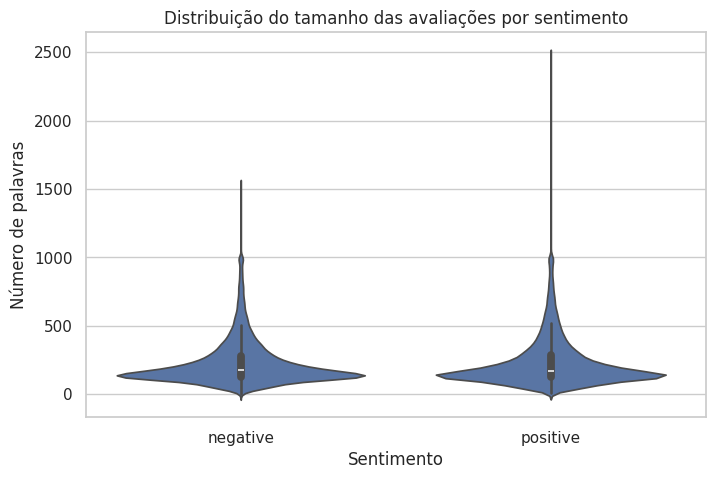

In [46]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="sentiment", y="review_length_words", order=["negative", "positive"])
plt.title("Distribuição do tamanho das avaliações por sentimento")
plt.xlabel("Sentimento")
plt.ylabel("Número de palavras")
plt.show()

### Interpretação

A análise do tamanho das avaliações indica se textos positivos e negativos possuem padrões distintos de extensão. Mesmo que o tamanho do texto isoladamente não seja suficiente para classificar o sentimento, ele ajuda a compreender a estrutura da base.

## 5.3 Presença de HTML e pontuação

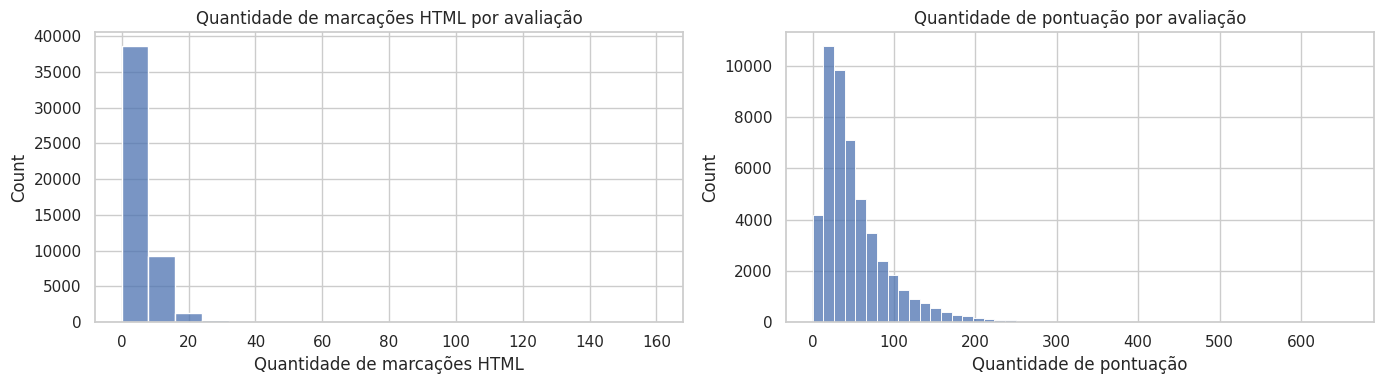

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x="html_count", bins=20, ax=axes[0])
axes[0].set_title("Quantidade de marcações HTML por avaliação")
axes[0].set_xlabel("Quantidade de marcações HTML")

sns.histplot(data=df, x="punctuation_count", bins=50, ax=axes[1])
axes[1].set_title("Quantidade de pontuação por avaliação")
axes[1].set_xlabel("Quantidade de pontuação")

plt.tight_layout()
plt.show()

### Interpretação

A presença de marcações HTML, como `<br />`, indica necessidade de limpeza textual. A pontuação também pode gerar ruído na vetorização, dependendo da abordagem escolhida.

## 5.4 Palavras mais frequentes por sentimento

In [ ]:
def basic_clean_text(text):
    text = str(text)
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"<.*?>", " ", text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["review_clean_eda"] = df["review"].apply(basic_clean_text)

stop_words = set(ENGLISH_STOP_WORDS)

def get_top_words(texts, n=25):
    words = []
    for text in texts:
        words.extend([w for w in text.split() if w not in stop_words and len(w) > 2])
    return pd.DataFrame(Counter(words).most_common(n), columns=["word", "count"])

top_positive = get_top_words(df.loc[df["sentiment"] == "positive", "review_clean_eda"], n=25)
top_negative = get_top_words(df.loc[df["sentiment"] == "negative", "review_clean_eda"], n=25)

display(top_positive.head())
display(top_negative.head())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_positive, y="word", x="count", ax=axes[0])
axes[0].set_title("Top palavras — avaliações positivas")
axes[0].set_xlabel("Frequência")
axes[0].set_ylabel("Palavra")

sns.barplot(data=top_negative, y="word", x="count", ax=axes[1])
axes[1].set_title("Top palavras — avaliações negativas")
axes[1].set_xlabel("Frequência")
axes[1].set_ylabel("Palavra")

plt.tight_layout()
plt.show()

### Interpretação

A frequência de palavras ajuda a identificar termos recorrentes em cada classe. Entretanto, palavras frequentes nem sempre são as mais discriminativas. Por isso, na modelagem serão utilizadas técnicas como Bag of Words e TF-IDF.

# 6. Preparação dos dados

A limpeza textual e a vetorização serão inseridas em pipelines do `scikit-learn`, permitindo que transformações sejam ajustadas somente nos dados de treino durante o treinamento e a validação.

In [ ]:
def clean_text_for_model(text):
    text = str(text)
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
X = df["review"]
y = df["target"]

print("X:", X.shape)
print("y:", y.shape)
print("Distribuição da variável-alvo:")
print(y.value_counts(normalize=True).round(4))

# 7. Divisão treino/teste

Será utilizada divisão 80/20 com estratificação pela variável-alvo. O conjunto de teste será mantido separado da otimização para evitar vazamento de dados.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True).round(4))

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True).round(4))

# 8. Funções auxiliares de avaliação

In [ ]:
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metrics = {
        "modelo": model_name,
        "accuracy_train": accuracy_score(y_train, y_pred_train),
        "accuracy_test": accuracy_score(y_test, y_pred_test),
        "precision_test": precision_score(y_test, y_pred_test),
        "recall_test": recall_score(y_test, y_pred_test),
        "f1_test": f1_score(y_test, y_pred_test),
        "train_time_sec": train_time
    }

    try:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test)
        else:
            y_score = None

        if y_score is not None:
            metrics["roc_auc_test"] = roc_auc_score(y_test, y_score)
            metrics["avg_precision_test"] = average_precision_score(y_test, y_score)
        else:
            metrics["roc_auc_test"] = np.nan
            metrics["avg_precision_test"] = np.nan
    except Exception:
        metrics["roc_auc_test"] = np.nan
        metrics["avg_precision_test"] = np.nan

    return metrics, y_pred_test


def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de confusão — {model_name}")
    plt.show()


def show_classification_report(y_true, y_pred):
    print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

# 9. Baseline

O baseline será o `DummyClassifier(strategy="most_frequent")`, que sempre prevê a classe mais frequente.

In [ ]:
baseline_model = Pipeline(steps=[
    ("dummy", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

baseline_metrics, baseline_pred = evaluate_model(
    "Baseline — DummyClassifier",
    baseline_model,
    X_train,
    y_train,
    X_test,
    y_test
)

baseline_metrics

In [ ]:
plot_confusion_matrix("Baseline — DummyClassifier", y_test, baseline_pred)
show_classification_report(y_test, baseline_pred)

# 10. Modelos candidatos

Serão avaliados:

1. Multinomial Naive Bayes com CountVectorizer.
2. Multinomial Naive Bayes com TF-IDF.
3. Regressão Logística com TF-IDF.
4. Linear SVM com TF-IDF.

In [ ]:
models = {
    "Naive Bayes — CountVectorizer": Pipeline(steps=[
        ("vectorizer", CountVectorizer(
            preprocessor=clean_text_for_model,
            stop_words="english",
            max_features=30000,
            ngram_range=(1, 1)
        )),
        ("classifier", MultinomialNB())
    ]),

    "Naive Bayes — TF-IDF": Pipeline(steps=[
        ("vectorizer", TfidfVectorizer(
            preprocessor=clean_text_for_model,
            stop_words="english",
            max_features=30000,
            ngram_range=(1, 1)
        )),
        ("classifier", MultinomialNB())
    ]),

    "Logistic Regression — TF-IDF": Pipeline(steps=[
        ("vectorizer", TfidfVectorizer(
            preprocessor=clean_text_for_model,
            stop_words="english",
            max_features=30000,
            ngram_range=(1, 2)
        )),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Linear SVM — TF-IDF": Pipeline(steps=[
        ("vectorizer", TfidfVectorizer(
            preprocessor=clean_text_for_model,
            stop_words="english",
            max_features=30000,
            ngram_range=(1, 2)
        )),
        ("classifier", LinearSVC(
            random_state=RANDOM_STATE
        ))
    ])
}

# 11. Treinamento e avaliação dos modelos candidatos

In [ ]:
results = [baseline_metrics]
predictions = {"Baseline — DummyClassifier": baseline_pred}
trained_models = {"Baseline — DummyClassifier": baseline_model}

for name, model in models.items():
    print(f"Treinando: {name}")
    metrics, y_pred = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results.append(metrics)
    predictions[name] = y_pred
    trained_models[name] = model
    print(metrics)
    print("-" * 80)

results_df = pd.DataFrame(results).sort_values("f1_test", ascending=False)
results_df

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x="f1_test", y="modelo")
plt.title("Comparação dos modelos por F1-score no teste")
plt.xlabel("F1-score")
plt.ylabel("Modelo")
plt.xlim(0, 1)
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x="accuracy_test", y="modelo")
plt.title("Comparação dos modelos por acurácia no teste")
plt.xlabel("Acurácia")
plt.ylabel("Modelo")
plt.xlim(0, 1)
plt.show()

### Interpretação

A comparação verifica se os modelos treinados superam o baseline. Em uma base balanceada, acurácia e F1-score são métricas úteis, mas o F1-score fornece visão mais equilibrada por combinar precisão e recall.

# 12. Relatórios e matrizes de confusão dos principais modelos

In [ ]:
for name in results_df["modelo"].head(3):
    print("=" * 100)
    print(name)
    print("=" * 100)
    show_classification_report(y_test, predictions[name])
    plot_confusion_matrix(name, y_test, predictions[name])

# 13. Otimização de hiperparâmetros

A otimização será feita na Regressão Logística com TF-IDF, por ser um modelo interpretável, eficiente e adequado para classificação textual.

A busca será feita com `GridSearchCV`, usando validação cruzada apenas no conjunto de treino.

In [ ]:
logreg_pipeline = Pipeline(steps=[
    ("vectorizer", TfidfVectorizer(
        preprocessor=clean_text_for_model,
        stop_words="english",
        max_features=30000
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_grid = {
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "vectorizer__min_df": [2, 5],
    "classifier__C": [0.5, 1.0, 2.0]
}

grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start

print("Tempo de otimização:", round(grid_time, 2), "segundos")
print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor F1 médio na validação cruzada:", round(grid_search.best_score_, 4))

# 14. Avaliação final do modelo otimizado

In [ ]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    y_score_best = best_model.predict_proba(X_test)[:, 1]
else:
    y_score_best = best_model.decision_function(X_test)

best_metrics = {
    "modelo": "Logistic Regression — TF-IDF otimizado",
    "accuracy_test": accuracy_score(y_test, y_pred_best),
    "precision_test": precision_score(y_test, y_pred_best),
    "recall_test": recall_score(y_test, y_pred_best),
    "f1_test": f1_score(y_test, y_pred_best),
    "roc_auc_test": roc_auc_score(y_test, y_score_best),
    "avg_precision_test": average_precision_score(y_test, y_score_best)
}

best_metrics

In [ ]:
show_classification_report(y_test, y_pred_best)
plot_confusion_matrix("Logistic Regression — TF-IDF otimizado", y_test, y_pred_best)

# 15. Curva ROC e curva Precision-Recall

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_score_best)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_score_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_score_best):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
plt.title("Curva ROC — Modelo otimizado")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, label=f"AP = {average_precision_score(y_test, y_score_best):.4f}")
plt.title("Curva Precision-Recall — Modelo otimizado")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# 16. Comparação final dos modelos

In [ ]:
final_results_df = pd.concat([
    results_df,
    pd.DataFrame([best_metrics])
], ignore_index=True)

final_results_df = final_results_df.sort_values("f1_test", ascending=False)
final_results_df

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=final_results_df, x="f1_test", y="modelo")
plt.title("Comparação final dos modelos — F1-score")
plt.xlabel("F1-score no teste")
plt.ylabel("Modelo")
plt.xlim(0, 1)
plt.show()

# 17. Análise de overfitting e underfitting

Para avaliar sinais de overfitting ou underfitting, compara-se o desempenho em treino e teste. Diferença muito grande entre treino e teste pode indicar overfitting. Desempenhos baixos em ambos podem indicar underfitting.

In [ ]:
overfit_df = final_results_df.copy()
if "accuracy_train" in overfit_df.columns:
    overfit_df["gap_accuracy"] = overfit_df["accuracy_train"] - overfit_df["accuracy_test"]
overfit_df

# 18. Interpretação do modelo: termos mais relevantes

A Regressão Logística permite interpretar os coeficientes associados aos termos do TF-IDF. Termos com coeficientes positivos contribuem para a classe positiva; termos com coeficientes negativos contribuem para a classe negativa.

In [ ]:
def show_top_terms_logreg(model, top_n=25):
    vectorizer = model.named_steps["vectorizer"]
    classifier = model.named_steps["classifier"]

    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = classifier.coef_[0]

    top_positive_idx = np.argsort(coefs)[-top_n:][::-1]
    top_negative_idx = np.argsort(coefs)[:top_n]

    positive_terms = pd.DataFrame({
        "term": feature_names[top_positive_idx],
        "coef": coefs[top_positive_idx]
    })

    negative_terms = pd.DataFrame({
        "term": feature_names[top_negative_idx],
        "coef": coefs[top_negative_idx]
    })

    return positive_terms, negative_terms

positive_terms, negative_terms = show_top_terms_logreg(best_model, top_n=25)

display(positive_terms)
display(negative_terms)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=positive_terms, y="term", x="coef", ax=axes[0])
axes[0].set_title("Termos mais associados a avaliações positivas")
axes[0].set_xlabel("Coeficiente")
axes[0].set_ylabel("Termo")

sns.barplot(data=negative_terms, y="term", x="coef", ax=axes[1])
axes[1].set_title("Termos mais associados a avaliações negativas")
axes[1].set_xlabel("Coeficiente")
axes[1].set_ylabel("Termo")

plt.tight_layout()
plt.show()

# 19. Análise de erros

A análise de erros ajuda a compreender limitações do modelo, como ironia, ambiguidades, avaliações mistas ou textos com vocabulário incomum.

In [ ]:
errors_df = pd.DataFrame({
    "review": X_test,
    "true_label": y_test,
    "pred_label": y_pred_best,
    "score_positive": y_score_best
}).copy()

errors_df["true_sentiment"] = errors_df["true_label"].map({0: "negative", 1: "positive"})
errors_df["pred_sentiment"] = errors_df["pred_label"].map({0: "negative", 1: "positive"})

errors_only = errors_df[errors_df["true_label"] != errors_df["pred_label"]].copy()
print("Quantidade de erros:", len(errors_only))
print("Taxa de erro:", round(len(errors_only) / len(errors_df), 4))

errors_only.head(10)

In [ ]:
false_positives = errors_only[
    (errors_only["true_label"] == 0) & (errors_only["pred_label"] == 1)
].sort_values("score_positive", ascending=False)

false_negatives = errors_only[
    (errors_only["true_label"] == 1) & (errors_only["pred_label"] == 0)
].sort_values("score_positive", ascending=True)

print("Falsos positivos:")
display(false_positives[["review", "true_sentiment", "pred_sentiment", "score_positive"]].head(5))

print("Falsos negativos:")
display(false_negatives[["review", "true_sentiment", "pred_sentiment", "score_positive"]].head(5))

### Discussão da análise de erros

Os erros podem ocorrer por diversos motivos:

- avaliações com sentimentos mistos;
- ironia ou sarcasmo;
- textos longos com opiniões contraditórias;
- termos raros ou ambíguos;
- presença de negações difíceis de capturar com vetorização simples;
- contexto semântico que modelos lineares não capturam plenamente.

# 20. Checklist do MVP

## Definição do problema

- **Descrição:** classificar avaliações textuais de filmes como positivas ou negativas.
- **Objetivo:** prever automaticamente o sentimento de uma avaliação.
- **Tipo:** classificação supervisionada binária.
- **Justificativa:** há exemplos rotulados e padrões textuais que podem ser aprendidos.

## Descrição dos dados

- **Dataset:** IMDB Dataset of 50K Movie Reviews.
- **Fonte:** Kaggle.
- **Atributos:** `review` e `sentiment`.
- **Variável-alvo:** `sentiment`.

## Preparação dos dados

- Remoção de HTML.
- Conversão para minúsculas.
- Remoção de URLs, pontuação e números.
- Vetorização por CountVectorizer e TF-IDF.
- Uso de pipelines para evitar vazamento de dados.

## Divisão dos dados

- Divisão treino/teste 80/20.
- Estratificação pela variável-alvo.
- Teste mantido separado da otimização.

## Modelagem

- Baseline: DummyClassifier.
- Modelos candidatos: Naive Bayes, Logistic Regression e Linear SVM.

## Otimização

- GridSearchCV aplicado à Regressão Logística com TF-IDF.
- Hiperparâmetros ajustados: `C`, `min_df`, `ngram_range`.
- Critério de seleção: F1-score em validação cruzada.

## Avaliação

- Métricas: accuracy, precision, recall, F1-score, ROC AUC, Average Precision.
- Matriz de confusão.
- Classification report.
- Análise de erros.

# 21. Conclusão final

O MVP desenvolveu uma solução de Machine Learning para classificação de sentimentos em avaliações de filmes do IMDB. O problema foi formulado como classificação supervisionada binária, utilizando o texto da avaliação como variável de entrada e o sentimento como variável-alvo.

A análise exploratória mostrou que a base é balanceada entre avaliações positivas e negativas. Também foram identificados ruídos textuais, como HTML e pontuação, justificando a etapa de pré-processamento.

Foram avaliados um baseline e diferentes modelos candidatos, incluindo Naive Bayes, Regressão Logística e Linear SVM, combinados com CountVectorizer e TF-IDF. A Regressão Logística com TF-IDF foi escolhida para otimização por apresentar bom desempenho, interpretabilidade e adequação ao problema.

Como limitações, destacam-se a simplicidade da representação textual, a dificuldade de lidar com ironia, ambiguidades e avaliações mistas, além da ausência de modelos semânticos mais avançados. Como próximos passos, poderiam ser testados embeddings, modelos baseados em transformers, lematização mais sofisticada e técnicas de explicabilidade mais avançadas.

# 22. Salvamento de artefatos

A célula abaixo salva o melhor modelo treinado em arquivo `.joblib`.

In [ ]:
import joblib

artifact_path = "best_imdb_sentiment_model.joblib"
joblib.dump(best_model, artifact_path)

print(f"Modelo salvo em: {artifact_path}")